Optimal First Bid: 790
Expected Profit from First Bid: 63.24


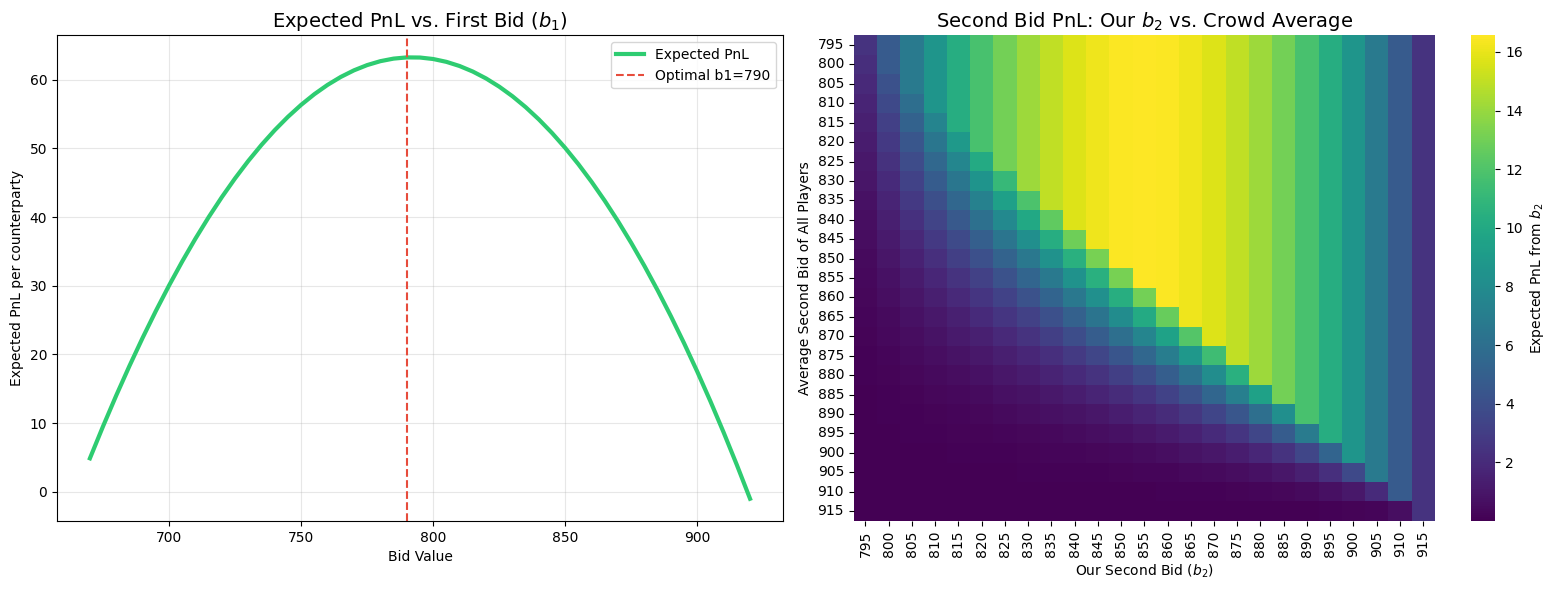

In [11]:
# Round 3 Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
PRICE_FAIR = 920
R_MIN, R_MAX, STEP = 670, 920, 5
RESERVES = np.arange(R_MIN, R_MAX + STEP, STEP)
N_RESERVES = len(RESERVES)

# --- 1. First Bid Optimization ---
b1_range = np.arange(R_MIN, R_MAX + STEP, STEP)
profits_b1 = [(PRICE_FAIR - b) * np.sum(RESERVES <= b) / N_RESERVES for b in b1_range]
best_b1 = b1_range[np.argmax(profits_b1)]

print(f"Optimal First Bid: {best_b1}")
print(f"Expected Profit from First Bid: {max(profits_b1):.2f}")

# --- 2. Second Bid Game Theory Analysis ---
# We assume we bid best_b1 for the first round. 
# The second bid targets the remaining pool: R > best_b1.
remaining_reserves = RESERVES[RESERVES > best_b1]

# Define range for our bid and the crowd average
# Usually b2 > b1 to be effective.
b2_range = np.arange(best_b1 + STEP, R_MAX, STEP)
avg_range = np.arange(best_b1 + STEP, R_MAX, STEP)

# Calculate PnL Matrix
pnl_matrix = np.zeros((len(avg_range), len(b2_range)))

for i, avg_b2 in enumerate(avg_range):
    for j, our_b2 in enumerate(b2_range):
        expected_pnl = 0
        for r in remaining_reserves:
            if our_b2 >= r:
                margin = PRICE_FAIR - our_b2
                if our_b2 > avg_b2:
                    pnl = margin
                else:
                    # Cubic penalty applied if we are below or equal to average
                    penalty = ((PRICE_FAIR - avg_b2) / (PRICE_FAIR - our_b2))**3
                    pnl = margin * penalty
                expected_pnl += pnl
        pnl_matrix[i, j] = expected_pnl / N_RESERVES

# --- 3. Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: First Bid Profit Curve
axes[0].plot(b1_range, profits_b1, color='#2ecc71', lw=3, label='Expected PnL')
axes[0].axvline(best_b1, color='#e74c3c', linestyle='--', label=f'Optimal b1={best_b1}')
axes[0].set_title('Expected PnL vs. First Bid ($b_1$)', fontsize=14)
axes[0].set_xlabel('Bid Value')
axes[0].set_ylabel('Expected PnL per counterparty')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Second Bid Heatmap
sns.heatmap(pnl_matrix, xticklabels=b2_range, yticklabels=avg_range, 
            cmap='viridis', ax=axes[1], cbar_kws={'label': 'Expected PnL from $b_2$'})
axes[1].set_title('Second Bid PnL: Our $b_2$ vs. Crowd Average', fontsize=14)
axes[1].set_xlabel('Our Second Bid ($b_2$)')
axes[1].set_ylabel('Average Second Bid of All Players')

plt.tight_layout()
plt.show()

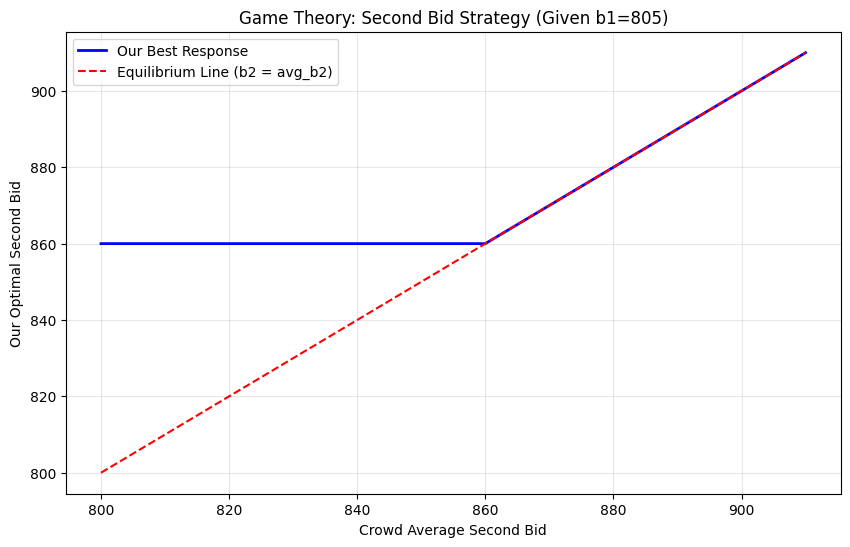

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
FAIR_PRICE = 920
R_MIN, R_MAX, STEP = 670, 920, 5
RESERVES = np.arange(R_MIN, R_MAX + STEP, STEP)
N = len(RESERVES)

def calculate_pnl(b1, b2, avg_b2):
    # Round 1 Trades
    r1_trades = RESERVES[RESERVES <= b1]
    pnl1 = sum(FAIR_PRICE - b1 for _ in r1_trades)
    
    # Round 2 Trades (Only those who didn't trade in R1)
    r2_candidates = RESERVES[(RESERVES > b1) & (RESERVES <= b2)]
    pnl2 = 0
    for _ in r2_candidates:
        margin = FAIR_PRICE - b2
        if b2 > avg_b2:
            pnl2 += margin
        else:
            # Applying the cubic penalty factor
            penalty = ((FAIR_PRICE - avg_b2) / (FAIR_PRICE - b2))**3
            pnl2 += margin * penalty
            
    return (pnl1 + pnl2) / N

# Simulation
b1_fixed = 805
b2_choices = np.arange(800, 915, STEP)
avg_choices = np.arange(800, 915, STEP)

# Find the "Best Response" for every possible crowd average
best_responses = []
for avg in avg_choices:
    pnls = [calculate_pnl(b1_fixed, b2, avg) for b2 in b2_choices]
    best_responses.append(b2_choices[np.argmax(pnls)])

# Plotting the Game Theory
plt.figure(figsize=(10, 6))
plt.plot(avg_choices, best_responses, label='Our Best Response', color='blue', lw=2)
plt.plot(avg_choices, avg_choices, label='Equilibrium Line (b2 = avg_b2)', color='red', linestyle='--')

# Identify the Equilibrium (where our best response meets the average)
# This is where the crowd will likely "cluster"
plt.title(f'Game Theory: Second Bid Strategy (Given b1={b1_fixed})')
plt.xlabel('Crowd Average Second Bid')
plt.ylabel('Our Optimal Second Bid')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()